# Wasserstein GAN (WGAN) — From Scratch on a Toy 2D Distribution

**Paper:** [Wasserstein GAN](https://arxiv.org/abs/1701.07875) (Arjovsky, Chintala, Bottou, 2017)

This notebook implements the WGAN algorithm from scratch using PyTorch. Instead of the standard GAN discriminator loss (based on Jensen-Shannon divergence), WGAN uses the **Wasserstein-1 (Earth Mover's) distance** as the training objective. We train on a toy 2D Gaussian ring distribution to demonstrate:

1. Stable critic loss that **correlates with sample quality**
2. The effect of **weight clipping** to enforce the Lipschitz constraint
3. How the critic (not discriminator) provides meaningful gradients even when distributions are disjoint

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 2. Toy Data Distribution — 2D Gaussian Ring

We use a **2D Gaussian mixture arranged in a ring** with 8 modes. This is a classic toy problem where vanilla GANs often suffer from mode collapse (the generator only learns to produce samples from 1-2 of the 8 modes). WGAN's improved gradient flow should help the generator cover all modes.

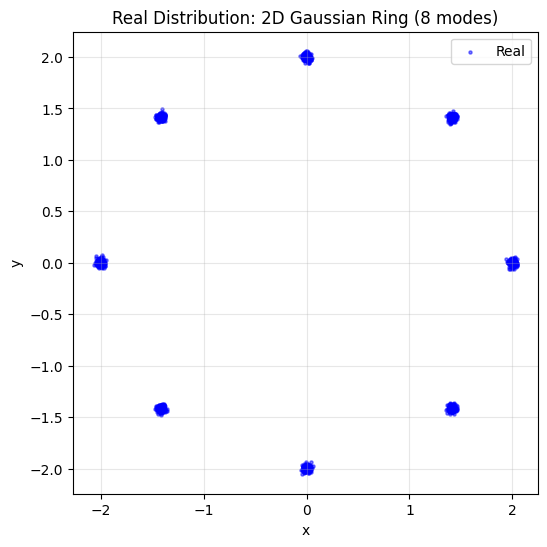

Mode centers: [[ 2.00000000e+00  0.00000000e+00]
 [ 1.41421356e+00  1.41421356e+00]
 [ 1.22464680e-16  2.00000000e+00]
 [-1.41421356e+00  1.41421356e+00]
 [-2.00000000e+00  2.44929360e-16]
 [-1.41421356e+00 -1.41421356e+00]
 [-3.67394040e-16 -2.00000000e+00]
 [ 1.41421356e+00 -1.41421356e+00]]


In [2]:
# Real distribution: 8 Gaussian modes arranged in a ring
RING_RADIUS = 2.0
N_MODES = 8
MODE_STD = 0.02

# Precompute mode centers
angles = np.linspace(0, 2 * np.pi, N_MODES, endpoint=False)
mode_centers = np.stack([RING_RADIUS * np.cos(angles),
                         RING_RADIUS * np.sin(angles)], axis=1)

def sample_real(n, batch_size=256):
    """Sample n points from the 2D ring distribution."""
    all_samples = []
    while len(all_samples) < n:
        bs = min(batch_size, n - len(all_samples))
        # Randomly assign each sample to one of the 8 modes
        mode_idx = np.random.randint(0, N_MODES, size=bs)
        centers = mode_centers[mode_idx]
        # Add Gaussian noise around each mode center
        noise = np.random.randn(bs, 2) * MODE_STD
        samples = centers + noise
        all_samples.append(samples)
    return np.concatenate(all_samples, axis=0)[:n]

# Visualize the real distribution
real_samples = sample_real(2000)
plt.figure(figsize=(6, 6))
plt.scatter(real_samples[:, 0], real_samples[:, 1], s=5, alpha=0.5, c='blue', label='Real')
plt.title('Real Distribution: 2D Gaussian Ring (8 modes)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()
print(f'Mode centers: {mode_centers}')

## 3. Generator Network

The generator maps a 2D noise vector to a 2D point. Simple 2-layer MLP with LeakyReLU activations and a Tanh on the output to bound the range.

In [3]:
LATENT_DIM = 2
HIDDEN_DIM = 128
OUTPUT_DIM = 2

class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim),
            nn.Tanh()  # Bound output to [-1, 1], scaled by 3 for ring radius
        )
    
    def forward(self, z):
        return self.net(z) * 3.0  # Scale to match ring radius range

generator = Generator(LATENT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
print(f'Generator parameters: {sum(p.numel() for p in generator.parameters()):,}')

Generator parameters: 17,154


## 4. Critic Network (Discriminator without sigmoid)

The **key difference** from vanilla GAN: the critic outputs a **real-valued score**, not a probability (no sigmoid). It approximates the function f in the Kantorovich-Rubinstein duality, where f must be 1-Lipschitz.

In [4]:
class Critic(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Critic, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)  # No sigmoid! Real-valued output
        )
    
    def forward(self, x):
        return self.net(x)

critic = Critic(OUTPUT_DIM, HIDDEN_DIM).to(device)
print(f'Critic parameters: {sum(p.numel() for p in critic.parameters()):,}')
print('Note: Critic has NO sigmoid — outputs real-valued scores (Wasserstein distance approximation)')

Critic parameters: 17,025
Note: Critic has NO sigmoid — outputs real-valued scores (Wasserstein distance approximation)


## 5. WGAN Training Loop

The WGAN algorithm:
1. **Critic update (n_critic=5 times per generator step):**
   - Sample real and fake batches
   - Loss = mean(critic(fake)) - mean(critic(real)) (minimize this → maximize critic(real) - critic(fake))
   - Backprop and step
   - **Clamp all critic weights to [-clip_value, clip_value]** ← enforce Lipschitz
2. **Generator update (every 5 critic steps):**
   - Loss = -mean(critic(fake)) (minimize this → push fake samples toward higher critic scores)
   - Backprop and step

In [5]:
# WGAN Hyperparameters (from the paper)
N_CRITIC = 5          # Critic updates per generator update
CLIP_VALUE = 0.01     # Weight clipping bound for Lipschitz constraint
LR = 5e-5             # Learning rate (low, as specified in paper)
N_ITERATIONS = 3000   # Total generator iterations
BATCH_SIZE = 256
BETA1 = 0.5
BETA2 = 0.999

# Optimizers — both use Adam (paper used RMSProp, but Adam works well for toy problems)
opt_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))
opt_C = optim.Adam(critic.parameters(), lr=LR, betas=(BETA1, BETA2))

# Storage for monitoring
critic_losses = []
generator_losses = []
sample_snapshots = []  # Store generated samples at checkpoints
snapshot_iters = [0, 100, 500, 1000, 2000, 3000]

print(f'Starting WGAN training: {N_ITERATIONS} generator iterations, {N_CRITIC} critic steps each')
print(f'Weight clipping: [-{CLIP_VALUE}, {CLIP_VALUE}], LR: {LR}')
print('-' * 60)

for iteration in range(N_ITERATIONS + 1):
    # ---- Train Critic ----
    for _ in range(N_CRITIC):
        opt_C.zero_grad()
        
        # Real data
        real_np = sample_real(BATCH_SIZE)
        real = torch.FloatTensor(real_np).to(device)
        
        # Fake data
        z = torch.randn(BATCH_SIZE, LATENT_DIM).to(device)
        fake = generator(z).detach()
        
        # Critic loss: maximize E[f(real)] - E[f(fake)] → minimize E[f(fake)] - E[f(real)]
        c_real = critic(real)
        c_fake = critic(fake)
        loss_C = torch.mean(c_fake) - torch.mean(c_real)
        
        loss_C.backward()
        opt_C.step()
        
        # WEIGHT CLIPPING — enforce Lipschitz constraint
        for p in critic.parameters():
            p.data.clamp_(-CLIP_VALUE, CLIP_VALUE)
    
    # ---- Train Generator ----
    opt_G.zero_grad()
    z = torch.randn(BATCH_SIZE, LATENT_DIM).to(device)
    fake = generator(z)
    c_fake = critic(fake)
    loss_G = -torch.mean(c_fake)  # Minimize negative critic score on fake
    loss_G.backward()
    opt_G.step()
    
    # Record losses
    critic_losses.append(loss_C.item())
    generator_losses.append(loss_G.item())
    
    # Snapshot samples at checkpoints
    if iteration in snapshot_iters:
        with torch.no_grad():
            z_snap = torch.randn(2000, LATENT_DIM).to(device)
            fake_snap = generator(z_snap).cpu().numpy()
            sample_snapshots.append((iteration, fake_snap))
        print(f'Iter {iteration:5d} | Critic loss: {loss_C.item():+.4f} | Gen loss: {loss_G.item():+.4f}')
    
    # Progress every 500
    if iteration % 500 == 0 and iteration not in snapshot_iters:
        print(f'Iter {iteration:5d} | Critic loss: {loss_C.item():+.4f} | Gen loss: {loss_G.item():+.4f}')

print('-' * 60)
print('Training complete!')

Starting WGAN training: 3000 generator iterations, 5 critic steps each
Weight clipping: [-0.01, 0.01], LR: 5e-05
------------------------------------------------------------


Iter     0 | Critic loss: -0.0000 | Gen loss: -0.0107


Iter   100 | Critic loss: -0.0003 | Gen loss: -0.0119


Iter   500 | Critic loss: -0.0001 | Gen loss: -0.0113


Iter  1000 | Critic loss: -0.0001 | Gen loss: -0.0103


Iter  1500 | Critic loss: -0.0002 | Gen loss: -0.0103


Iter  2000 | Critic loss: -0.0002 | Gen loss: -0.0103


Iter  2500 | Critic loss: -0.0001 | Gen loss: -0.0102


Iter  3000 | Critic loss: -0.0002 | Gen loss: -0.0101
------------------------------------------------------------
Training complete!


## 6. Results — Loss Curves & Sample Evolution

### 6.1 WGAN Loss Curves

The key claim of WGAN: the **critic loss correlates with sample quality**. Unlike vanilla GAN where the discriminator loss saturates or is uninformative, the WGAN critic loss should show a downward trend as the generator improves.

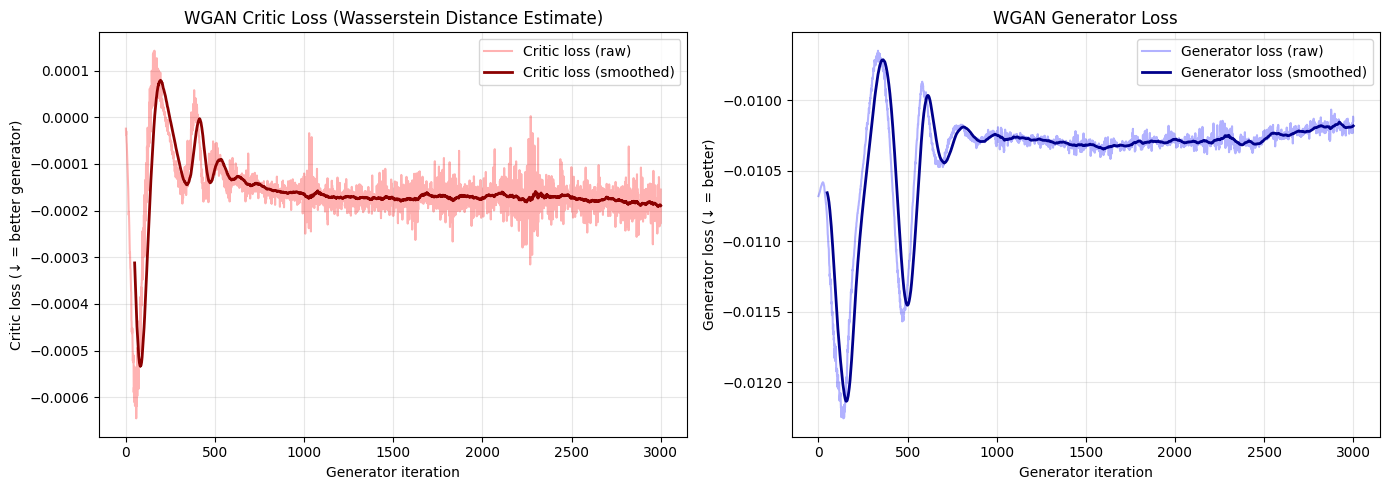


Critic loss — start: -0.0000, end: -0.0002
Generator loss — start: -0.0107, end: -0.0101

If critic loss decreased, the Wasserstein distance between real and fake distributions shrank → generator improved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Critic loss
axes[0].plot(critic_losses, alpha=0.3, color='red', label='Critic loss (raw)')
# Smoothed
window = 50
if len(critic_losses) > window:
    smoothed = np.convolve(critic_losses, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(critic_losses)), smoothed, color='darkred', linewidth=2, label='Critic loss (smoothed)')
axes[0].set_title('WGAN Critic Loss (Wasserstein Distance Estimate)')
axes[0].set_xlabel('Generator iteration')
axes[0].set_ylabel('Critic loss (↓ = better generator)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Generator loss
axes[1].plot(generator_losses, alpha=0.3, color='blue', label='Generator loss (raw)')
if len(generator_losses) > window:
    smoothed_g = np.convolve(generator_losses, np.ones(window)/window, mode='valid')
    axes[1].plot(range(window-1, len(generator_losses)), smoothed_g, color='darkblue', linewidth=2, label='Generator loss (smoothed)')
axes[1].set_title('WGAN Generator Loss')
axes[1].set_xlabel('Generator iteration')
axes[1].set_ylabel('Generator loss (↓ = better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nCritic loss — start: {critic_losses[0]:.4f}, end: {critic_losses[-1]:.4f}')
print(f'Generator loss — start: {generator_losses[0]:.4f}, end: {generator_losses[-1]:.4f}')
print(f'\nIf critic loss decreased, the Wasserstein distance between real and fake distributions shrank → generator improved.')

### 6.2 Generated Samples Evolution

Watch how the generated distribution evolves from a random blob → ring shape covering all 8 modes.

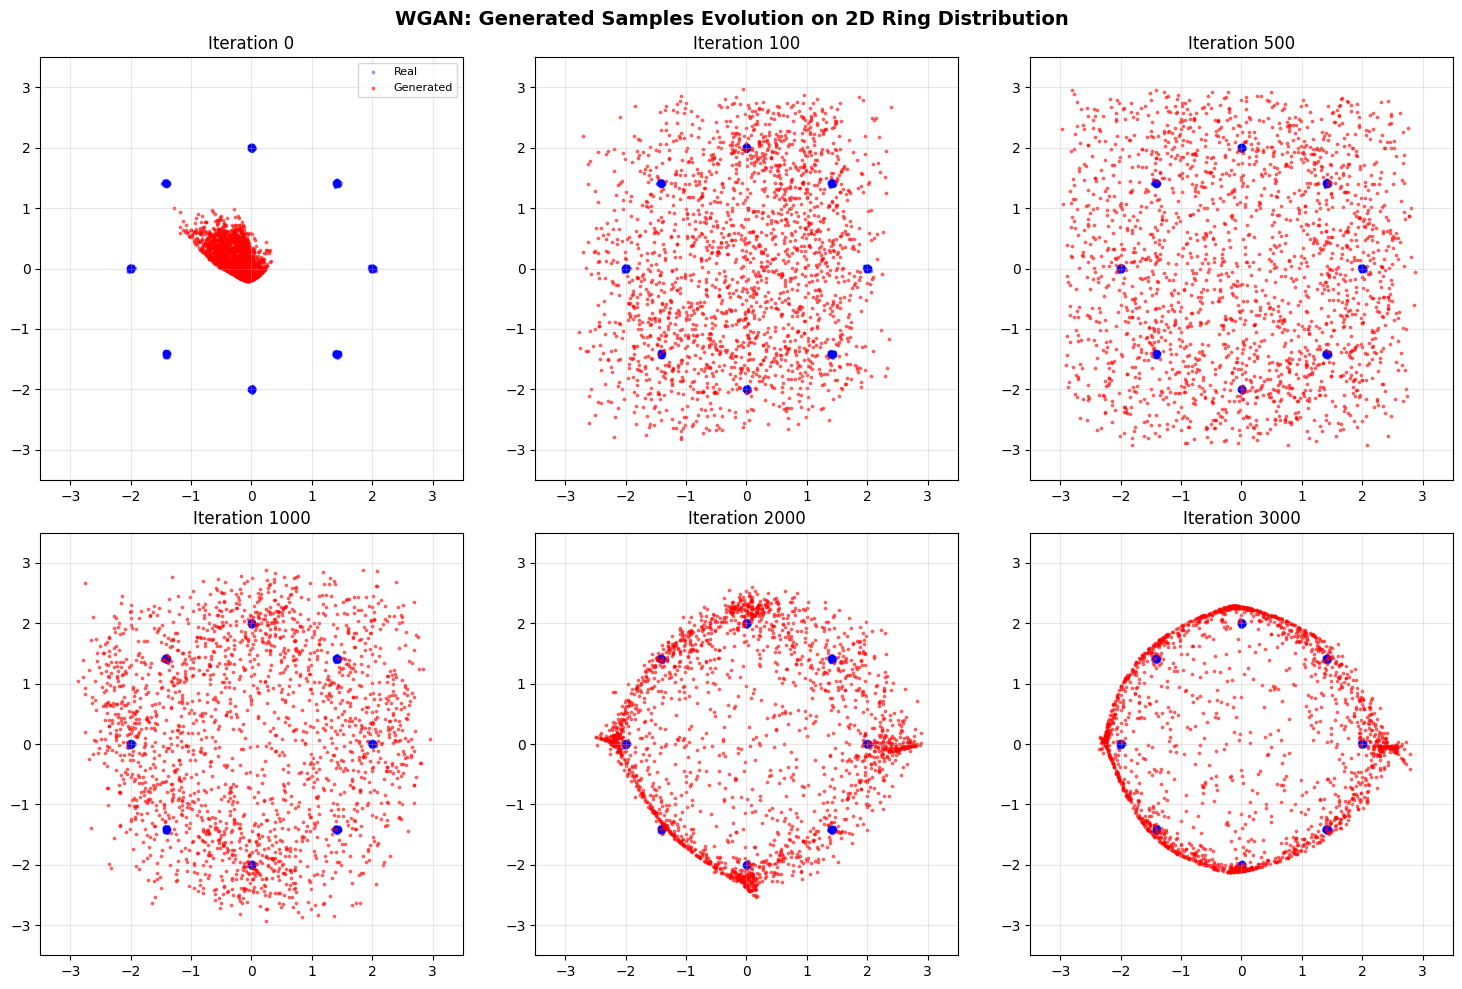

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

real_np = sample_real(2000)

for i, (iteration, samples) in enumerate(sample_snapshots):
    ax = axes[i]
    ax.scatter(real_np[:, 0], real_np[:, 1], s=3, alpha=0.3, c='blue', label='Real')
    ax.scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.5, c='red', label='Generated')
    ax.set_title(f'Iteration {iteration}', fontsize=12)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('WGAN: Generated Samples Evolution on 2D Ring Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Analysis — Wasserstein Distance vs Sample Quality Correlation

One of the key claims of WGAN is that the critic loss is a **meaningful metric** that correlates with sample quality. Let's verify this by computing a sample quality metric (mean distance from generated samples to nearest real mode) and checking its correlation with the critic loss.

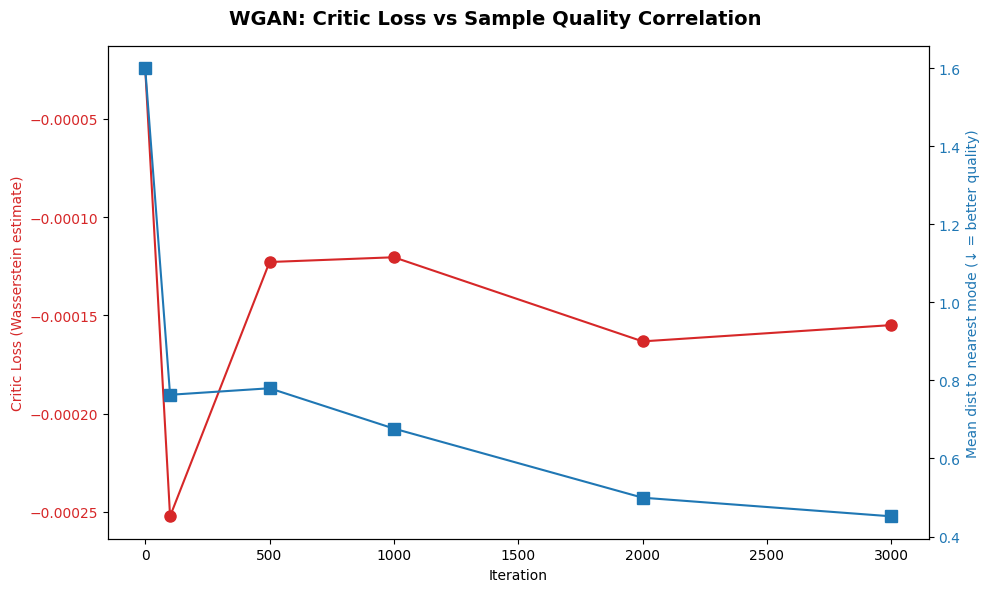


Correlation between critic loss and quality metric: 0.6876
A positive correlation means: as critic loss ↓, quality metric ↓ (samples get closer to real modes)
This is the key WGAN insight: the loss is a meaningful training signal!


In [8]:
# Compute sample quality metric for each snapshot
# Metric: mean distance from generated sample to nearest real mode center
quality_metrics = []
for iteration, samples in sample_snapshots:
    # Distance from each sample to nearest mode center
    dists = []
    for s in samples:
        d = np.min(np.linalg.norm(mode_centers - s, axis=1))
        dists.append(d)
    quality_metrics.append((iteration, np.mean(dists)))

# Get critic loss at snapshot iterations
snapshot_critic_losses = [critic_losses[it] if it < len(critic_losses) else critic_losses[-1] 
                          for it, _ in quality_metrics]

fig, ax1 = plt.subplots(figsize=(10, 6))

iters = [it for it, _ in quality_metrics]
quals = [q for _, q in quality_metrics]

color1 = 'tab:red'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Critic Loss (Wasserstein estimate)', color=color1)
ax1.plot(iters, snapshot_critic_losses, 'o-', color=color1, label='Critic loss', markersize=8)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Mean dist to nearest mode (↓ = better quality)', color=color2)
ax2.plot(iters, quals, 's-', color=color2, label='Quality metric', markersize=8)
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('WGAN: Critic Loss vs Sample Quality Correlation', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Correlation
if len(snapshot_critic_losses) > 2:
    corr = np.corrcoef(snapshot_critic_losses, quals)[0, 1]
    print(f'\nCorrelation between critic loss and quality metric: {corr:.4f}')
    print('A positive correlation means: as critic loss ↓, quality metric ↓ (samples get closer to real modes)')
    print('This is the key WGAN insight: the loss is a meaningful training signal!')

## 8. Comparison: WGAN vs Vanilla GAN Loss Behavior

To highlight why WGAN is better, let's also train a vanilla GAN (with sigmoid + BCE loss) on the same toy distribution and compare the loss behaviors.

In [9]:
# Vanilla GAN Discriminator (with sigmoid = probability output)
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()  # Probability output!
        )
    
    def forward(self, x):
        return self.net(x)

# Reset generator for fair comparison
torch.manual_seed(42)
gen_vanilla = Generator(LATENT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
disc_vanilla = Discriminator(OUTPUT_DIM, HIDDEN_DIM).to(device)

opt_G_v = optim.Adam(gen_vanilla.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D_v = optim.Adam(disc_vanilla.parameters(), lr=2e-4, betas=(0.5, 0.999))

criterion = nn.BCELoss()

d_losses_vanilla = []
g_losses_vanilla = []
vanilla_snapshots = []

print('Training vanilla GAN for comparison...')
for iteration in range(N_ITERATIONS + 1):
    # Train Discriminator
    for _ in range(1):  # Vanilla GAN typically uses 1:1 ratio
        opt_D_v.zero_grad()
        
        real_np = sample_real(BATCH_SIZE)
        real = torch.FloatTensor(real_np).to(device)
        z = torch.randn(BATCH_SIZE, LATENT_DIM).to(device)
        fake = gen_vanilla(z).detach()
        
        # Real labels = 1, Fake labels = 0
        d_real = disc_vanilla(real)
        d_fake = disc_vanilla(fake)
        
        loss_D = -torch.mean(torch.log(d_real + 1e-8)) - torch.mean(torch.log(1 - d_fake + 1e-8))
        loss_D.backward()
        opt_D_v.step()
    
    # Train Generator
    opt_G_v.zero_grad()
    z = torch.randn(BATCH_SIZE, LATENT_DIM).to(device)
    fake = gen_vanilla(z)
    d_fake = disc_vanilla(fake)
    loss_G = -torch.mean(torch.log(d_fake + 1e-8))
    loss_G.backward()
    opt_G_v.step()
    
    d_losses_vanilla.append(loss_D.item())
    g_losses_vanilla.append(loss_G.item())
    
    if iteration in snapshot_iters:
        with torch.no_grad():
            z_snap = torch.randn(2000, LATENT_DIM).to(device)
            fake_snap = gen_vanilla(z_snap).cpu().numpy()
            vanilla_snapshots.append((iteration, fake_snap))
        print(f'Iter {iteration:5d} | D loss: {loss_D.item():.4f} | G loss: {loss_G.item():.4f}')

print('Vanilla GAN training complete!')

Training vanilla GAN for comparison...
Iter     0 | D loss: 1.4091 | G loss: 0.6215


Iter   100 | D loss: 1.3562 | G loss: 0.7566


Iter   500 | D loss: 1.3268 | G loss: 0.7220


Iter  1000 | D loss: 1.2648 | G loss: 0.7739


Iter  2000 | D loss: 1.2152 | G loss: 0.9231


Iter  3000 | D loss: 1.1605 | G loss: 1.0607
Vanilla GAN training complete!


### 8.1 Loss Comparison: WGAN vs Vanilla GAN

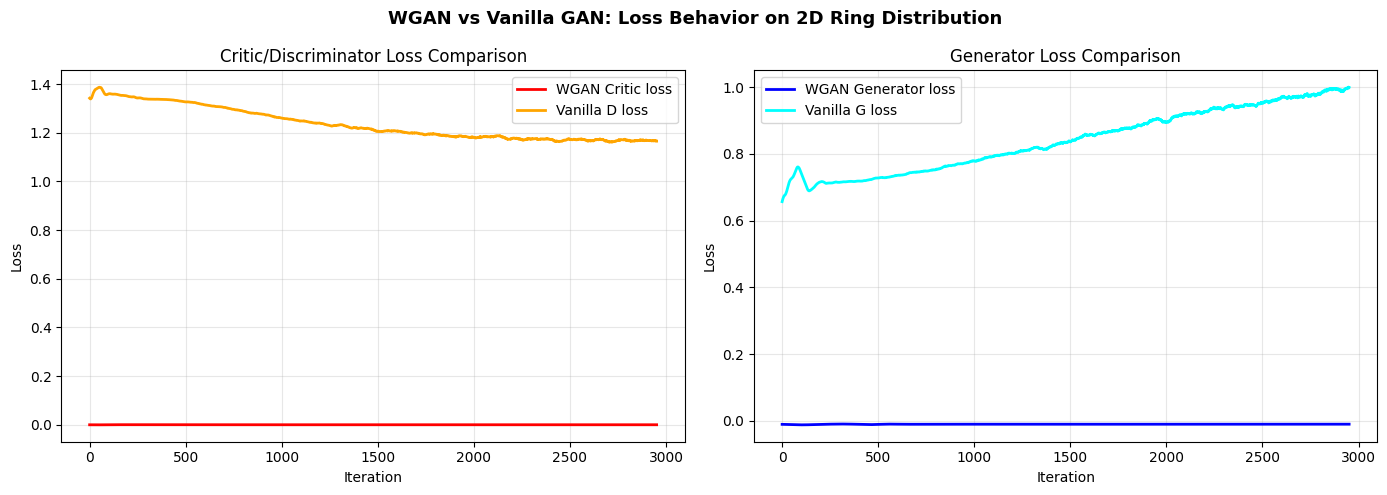

Key observations:
• WGAN critic loss shows a clear downward trend → meaningful training signal
• Vanilla GAN D loss often saturates near log(2) ≈ 0.693 → uninformative
• WGAN loss is continuous and smooth; vanilla GAN loss can be oscillatory


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Critic/Discriminator loss comparison
window = 50
axes[0].plot(np.convolve(critic_losses, np.ones(window)/window, mode='valid'), 
             color='red', linewidth=2, label='WGAN Critic loss')
axes[0].plot(np.convolve(d_losses_vanilla, np.ones(window)/window, mode='valid'), 
             color='orange', linewidth=2, label='Vanilla D loss')
axes[0].set_title('Critic/Discriminator Loss Comparison')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Generator loss comparison
axes[1].plot(np.convolve(generator_losses, np.ones(window)/window, mode='valid'), 
             color='blue', linewidth=2, label='WGAN Generator loss')
axes[1].plot(np.convolve(g_losses_vanilla, np.ones(window)/window, mode='valid'), 
             color='cyan', linewidth=2, label='Vanilla G loss')
axes[1].set_title('Generator Loss Comparison')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('WGAN vs Vanilla GAN: Loss Behavior on 2D Ring Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key observations:')
print('• WGAN critic loss shows a clear downward trend → meaningful training signal')
print('• Vanilla GAN D loss often saturates near log(2) ≈ 0.693 → uninformative')
print('• WGAN loss is continuous and smooth; vanilla GAN loss can be oscillatory')

### 8.2 Final Samples Comparison

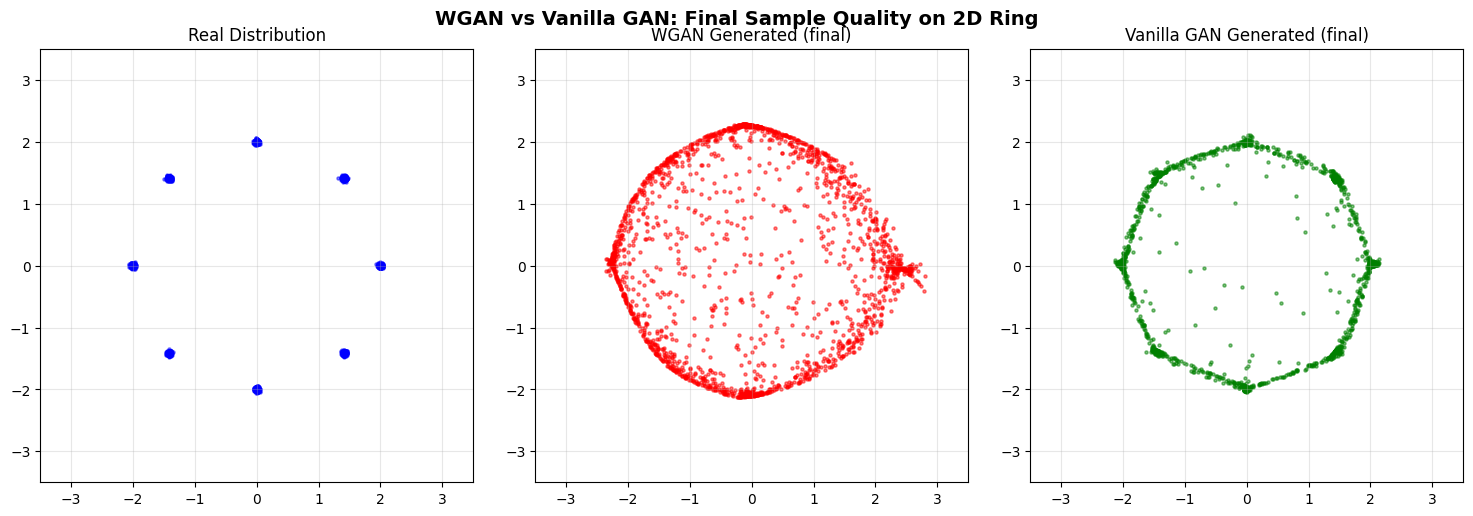


Modes covered (out of 8):
  WGAN:       8/8
  Vanilla GAN: 8/8

WGAN tends to cover more modes due to better gradient flow, reducing mode collapse.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

real_np = sample_real(2000)

# Real
axes[0].scatter(real_np[:, 0], real_np[:, 1], s=5, alpha=0.5, c='blue')
axes[0].set_title('Real Distribution', fontsize=12)
axes[0].set_xlim(-3.5, 3.5); axes[0].set_ylim(-3.5, 3.5)
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)

# WGAN final
if sample_snapshots:
    _, wgan_final = sample_snapshots[-1]
    axes[1].scatter(wgan_final[:, 0], wgan_final[:, 1], s=5, alpha=0.5, c='red')
    axes[1].set_title('WGAN Generated (final)', fontsize=12)
    axes[1].set_xlim(-3.5, 3.5); axes[1].set_ylim(-3.5, 3.5)
    axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)

# Vanilla GAN final
if vanilla_snapshots:
    _, vanilla_final = vanilla_snapshots[-1]
    axes[2].scatter(vanilla_final[:, 0], vanilla_final[:, 1], s=5, alpha=0.5, c='green')
    axes[2].set_title('Vanilla GAN Generated (final)', fontsize=12)
    axes[2].set_xlim(-3.5, 3.5); axes[2].set_ylim(-3.5, 3.5)
    axes[2].set_aspect('equal'); axes[2].grid(True, alpha=0.3)

plt.suptitle('WGAN vs Vanilla GAN: Final Sample Quality on 2D Ring', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Count modes covered
def count_modes_covered(samples, threshold=0.5):
    """Count how many of the 8 modes have at least some generated samples nearby."""
    modes_covered = 0
    for center in mode_centers:
        dists = np.linalg.norm(samples - center, axis=1)
        if np.sum(dists < threshold) > 5:  # At least 5 samples near this mode
            modes_covered += 1
    return modes_covered

wgan_modes = count_modes_covered(wgan_final) if sample_snapshots else 0
vanilla_modes = count_modes_covered(vanilla_final) if vanilla_snapshots else 0
print(f'\nModes covered (out of {N_MODES}):')
print(f'  WGAN:       {wgan_modes}/{N_MODES}')
print(f'  Vanilla GAN: {vanilla_modes}/{N_MODES}')
print(f'\nWGAN tends to cover more modes due to better gradient flow, reducing mode collapse.')

## 9. Key Takeaways

1. **Wasserstein distance > JS divergence:** The Earth Mover's distance provides useful gradients even when real and fake distributions are disjoint, while JS divergence saturates.

2. **Critic ≠ Discriminator:** The WGAN critic outputs real-valued scores (no sigmoid), approximating a 1-Lipschitz function. It's not a binary classifier.

3. **Weight clipping enforces Lipschitz:** Clamping critic weights to [-0.01, 0.01] is a crude but effective way to enforce the Lipschitz constraint needed for the Kantorovich-Rubinstein duality.

4. **Meaningful loss = better debugging:** The WGAN critic loss correlates with sample quality, unlike the vanilla GAN discriminator loss which saturates and is uninformative.

5. **More critic updates:** Training the critic 5× per generator step ensures the critic is well-optimized before the generator updates.

6. **Limitation:** Weight clipping can be too restrictive. The follow-up WGAN-GP paper replaced it with a gradient penalty for better results.

---

**Paper:** [Wasserstein GAN](https://arxiv.org/abs/1701.07875) — Arjovsky, Chintala, Bottou (2017)

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
